In [1]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
import pandas as pd

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p.preproc import utils, behavior
from gulp2p.preproc.tiff import Tiff

config loaded


In [2]:
BHV_DATA_FOLDER = Path(r'Z:\FlyVR\FlyVR data\Kerstin')
OUTPUT_FOLDER = Path(r"C:\Users\ahshenas\Desktop\live fly analysis")

## Compare tiff and bhv creation times

In [3]:
# do this for all bhv and tiffs in kerstins mimms folder
# Ignore time differences greater than 1 maybe 2 minutes (?)
# Need a way to synce up tiff and bhv files

In [4]:
from datetime import datetime, timedelta

In [5]:
tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS")
bhv_folder = Path(r"Z:\Live Fly Imaging data\unity\raw data")

In [6]:
def find_bhv_path_from_tiff(tiff_timestamp, bhv_folder=None):
    if bhv_folder is None:
        bhv_folder = Path(r"Z:\Live Fly Imaging data\unity\raw data")
    min_diff = None
    min_file = None
    for path in bhv_folder.rglob("*"):
        if not path.is_file():
            continue
        try:
            file_timestamp = utils.get_timestamp_from_string(path.name)
        except:
            continue

        time_diff = file_timestamp - tiff_timestamp
        if min_diff is None:
            min_diff = time_diff
            min_file = path
        if abs(time_diff) < abs(min_diff):
            min_diff = time_diff
            min_file = path
    return min_file, min_diff



In [7]:
tiff_paths = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    tiff_paths.append(path)

In [8]:
df_dicts = []
for tiff_path in tiff_paths:
    tiff_date = Tiff(tiff_path).metadata['date']
    tiff_timestamp = tiff_date.timestamp()
    bhv_path, min_diff = find_bhv_path_from_tiff(tiff_timestamp)
    bhv_date = datetime.fromtimestamp(utils.get_timestamp_from_string(bhv_path.name))
    df_dicts.append({"tiff_date": tiff_date,
                     "bhv_date": bhv_date})
dates_df = pd.DataFrame(df_dicts)

In [9]:
dates_df['diff'] = dates_df['tiff_date'] - dates_df['bhv_date']
dates_df

,tiff_date,bhv_date,diff
0,2023-11-17 16:21:05.428768,2023-11-20 12:56:35,-3 days +03:24:30.428768
1,2023-11-17 16:21:17.130715,2023-11-20 12:56:35,-3 days +03:24:42.130715
2,2023-11-17 16:21:17.986712,2023-11-20 12:56:35,-3 days +03:24:42.986712
3,2023-11-17 16:21:19.013707,2023-11-20 12:56:35,-3 days +03:24:44.013707
4,2023-11-17 16:21:19.808703,2023-11-20 12:56:35,-3 days +03:24:44.808703
...,...,...,...
185,2024-02-15 13:53:57.157975,2024-02-15 13:52:28,0 days 00:01:29.157975
186,2024-02-15 13:59:32.872966,2024-02-15 14:00:03,-1 days +23:59:29.872966
187,2024-02-15 14:01:31.519963,2024-02-15 14:00:03,0 days 00:01:28.519963
188,2024-02-15 14:07:45.325953,2024-02-15 14:06:17,0 days 00:01:28.325953


In [10]:
# tiff is created about 33 seconds after bhv file

In [11]:
dates_df.describe()

,diff
count,190
mean,-1 days +22:12:40.377500148
std,0 days 11:00:41.055893704
min,-3 days +03:24:30.428768
25%,0 days 00:00:17.797629250
50%,0 days 00:00:33.714027
75%,0 days 00:01:22.524943750
max,0 days 00:14:44.321816


In [12]:
import seaborn as sns

In [13]:
dates_df_filtered = dates_df[(dates_df["diff"] < timedelta(minutes=5)) & (dates_df["diff"] > timedelta(minutes=-5))]

In [14]:
dates_df_filtered.describe()

,diff
count,168
mean,0 days 00:00:37.140537553
std,0 days 00:01:03.012456622
min,-1 days +23:55:56.290211
25%,0 days 00:00:17.812803750
50%,0 days 00:00:27.592739500
75%,0 days 00:01:17.835057500
max,0 days 00:03:51.574860


In [15]:
dates_df_filtered

,tiff_date,bhv_date,diff
5,2023-11-28 18:20:46.428184,2023-11-28 18:20:40,0 days 00:00:06.428184
6,2023-11-28 18:20:53.709270,2023-11-28 18:20:40,0 days 00:00:13.709270
7,2023-11-28 18:21:00.975357,2023-11-28 18:20:40,0 days 00:00:20.975357
8,2023-11-28 18:21:08.250443,2023-11-28 18:20:40,0 days 00:00:28.250443
9,2023-11-28 18:21:15.534530,2023-11-28 18:20:40,0 days 00:00:35.534530
...,...,...,...
185,2024-02-15 13:53:57.157975,2024-02-15 13:52:28,0 days 00:01:29.157975
186,2024-02-15 13:59:32.872966,2024-02-15 14:00:03,-1 days +23:59:29.872966
187,2024-02-15 14:01:31.519963,2024-02-15 14:00:03,0 days 00:01:28.519963
188,2024-02-15 14:07:45.325953,2024-02-15 14:06:17,0 days 00:01:28.325953


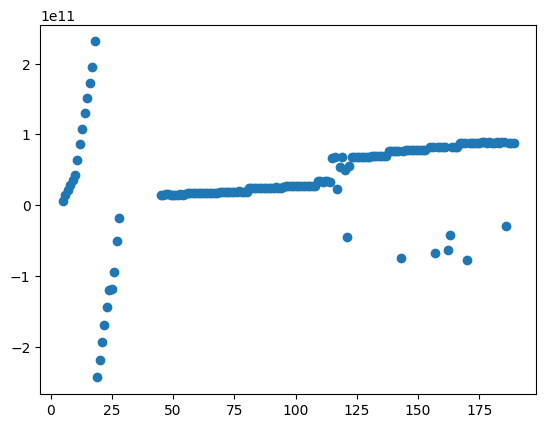

In [16]:
ax = plt.subplot()
ax.scatter(dates_df_filtered.index, dates_df_filtered['diff'])

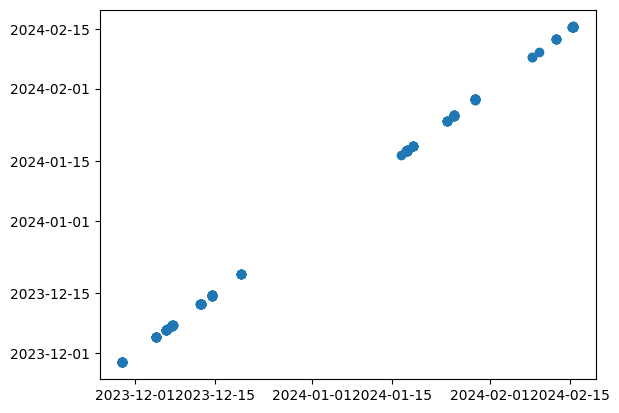

In [17]:
plt.scatter(dates_df_filtered['tiff_date'], dates_df_filtered['bhv_date'])

## Plot recording ranges over an experiment

In [18]:
from datetime import date

In [19]:
def convert_range_units(time_range):
    # Convert from timestamp to minutes since midnight
    date_day = date.fromtimestamp(time_range[0])
    new_range = []
    for timepoint in time_range:
        midnight_timestamp = datetime.combine(date_day, datetime.min.time()).timestamp()
        seconds_since_midnight = timepoint - midnight_timestamp
        hour_since_midnight = seconds_since_midnight / 60 / 60
        new_range.append(hour_since_midnight)
    return new_range

In [20]:
def get_tiff_range(tiff):
    tiff_start_time = tiff.metadata['date'].timestamp()
    tiff_length = tiff.length
    tiff_range = (tiff_start_time, tiff_start_time + tiff_length)
    return tiff_range

def get_bhv_range(bhv_path):
    bhv_start_time = utils.get_timestamp_from_string(bhv_path.name)
    bhv_length = utils.get_bhv_length(bhv_path)
    if bhv_length is None:
        bhv_length = 0
    bhv_range = (bhv_start_time, bhv_start_time + bhv_length)
    return bhv_range

In [21]:
def plot_range(range, ax, y, color="C0"):
    ax.plot(range, [y,y], c=color, marker='o', ms=2)

In [22]:
df_dicts = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    tiff = Tiff(path)
    df_dicts.append({"path": path,
                     "tiff": tiff,
                     "datetime": tiff.metadata['date']})

tiff_df = pd.DataFrame(df_dicts)

In [23]:
tiff_df['date'] = tiff_df['datetime'].apply(lambda x:x.date())
tiff_df['range'] = tiff_df['tiff'].apply(get_tiff_range)
tiff_df['range_sub_midnight'] = tiff_df['range'].apply(convert_range_units)

In [24]:
tiff_df

,path,tiff,datetime,date,range,range_sub_midnight
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2023-11-17 16:21:05.428768,2023-11-17,"(1700266865.428768, 1700267065.4843678)","[16.35150799108876, 16.407078991068733]"
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2023-11-17 16:21:17.130715,2023-11-17,"(1700266877.130715, 1700266928.6563148)","[16.35475853191482, 16.369071198569404]"
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2023-11-17 16:21:17.986712,2023-11-17,"(1700266877.986712, 1700266929.5126119)","[16.35499630888303, 16.369309058851666]"
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2023-11-17 16:21:19.013707,2023-11-17,"(1700266879.013707, 1700266930.538707)","[16.355281585256257, 16.36959408528275]"
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2023-11-17 16:21:19.808703,2023-11-17,"(1700266879.808703, 1700267199.2730029)","[16.355502417484917, 16.44424250079526]"
...,...,...,...,...,...,...
185,Z:\2PImaging\Kerstin\MIMS\20240215\20240215_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-02-15 13:53:57.157975,2024-02-15,"(1708034037.157975, 1708034332.095631)","[13.899210548599562, 13.981137675245604]"
186,Z:\2PImaging\Kerstin\MIMS\20240215\20240215_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-02-15 13:59:32.872966,2024-02-15,"(1708034372.872966, 1708034667.8140557)","[13.992464712791973, 14.074392793244785]"
187,Z:\2PImaging\Kerstin\MIMS\20240215\20240215_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-02-15 14:01:31.519963,2024-02-15,"(1708034491.519963, 1708034786.4541855)","[14.02542221195168, 14.107348384857177]"
188,Z:\2PImaging\Kerstin\MIMS\20240215\20240215_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-02-15 14:07:45.325953,2024-02-15,"(1708034865.325953, 1708035160.2790601)","[14.129257209168541, 14.211188627812597]"


In [25]:
df_dicts = []
for path in bhv_folder.rglob("*"):
    if path.suffix != ".json":
        continue
    if path.stem == "SessionParameters":
        continue
    bhv_timestamp = utils.get_timestamp_from_string(path.name)
    bhv_datetime = datetime.fromtimestamp(bhv_timestamp)
    df_dicts.append({"path": path,
                     "datetime": bhv_datetime})

bhv_df = pd.DataFrame(df_dicts)

In [26]:
bhv_df['date'] = bhv_df['datetime'].apply(lambda x:x.date())
bhv_df['range'] = bhv_df['path'].apply(get_bhv_range)
bhv_df['range_sub_midnight'] = bhv_df['range'].apply(convert_range_units)

In [27]:
bhv_df

,path,datetime,date,range,range_sub_midnight
0,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 10:49:54,2022-12-13,"(1670957394.0, 1670957993.446289)","[10.831666666666667, 10.998179524739584]"
1,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:09:47,2022-12-13,"(1670958587.0, 1670959186.4534302)","[11.163055555555555, 11.32957039727105]"
2,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:35:09,2022-12-13,"(1670960109.0, 1670960708.4599)","[11.585833333333333, 11.752349972195097]"
3,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:18:55,2022-12-14,"(1671041935.0, 1671042534.2382812)","[10.315277777777776, 10.481732855902777]"
4,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:29:39,2022-12-14,"(1671042579.0, 1671043178.4607544)","[10.494166666666667, 10.66068354288737]"
...,...,...,...,...,...
939,Z:\Live Fly Imaging data\unity\raw data\Kersti...,2024-01-24 11:27:51,2024-01-24,"(1706124471.0, 1706124830.2649841)","[11.464166666666667, 11.563962495591905]"
940,Z:\Live Fly Imaging data\unity\raw data\Kersti...,2024-01-24 11:35:36,2024-01-24,"(1706124936.0, 1706125295.2893066)","[11.593333333333334, 11.693135918511285]"
941,Z:\Live Fly Imaging data\unity\raw data\Kersti...,2024-01-24 11:38:08,2024-01-24,"(1706125088.0, 1706125447.2528687)","[11.635555555555555, 11.735348019070097]"
942,Z:\Live Fly Imaging data\unity\raw data\Kersti...,2024-01-24 11:39:55,2024-01-24,"(1706125195.0, 1706125554.2461548)","[11.665277777777778, 11.765068376329209]"


In [28]:
def plot_expt_file_ranges(expt_date, tiff_df, bhv_df, ax):

    tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
    bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

    # plot all ranges and see if they can be aligned by shifting
    ax.set_ylim([0.5, 2.5])
    for index, tiff_range in tiff_df_subset['range_sub_midnight'].items():
        plot_range(tiff_range, ax, y=1, color="C0")
    for index, bhv_range in bhv_df_subset['range_sub_midnight'].items():
        plot_range(bhv_range, ax, y=2, color="C1")

    ax.set_yticks([1, 2], ["tiff", "bhv"])
    ax.set_title(expt_date)

    min_diffs = []
    for i, tiff_row in tiff_df_subset.iterrows():
        # print(tiff_row['path'].name)
        tiff_ts = tiff_row['datetime'].timestamp()
        min_diff = None
        for j, bhv_row in bhv_df_subset.iterrows():
            bhv_ts = bhv_row['datetime'].timestamp()
            diff = bhv_ts - tiff_ts
            if min_diff is None:
                min_diff = diff
            if diff > 0:
                continue
            if abs(diff) < abs(min_diff):
                min_diff = diff
                bhv_path = bhv_row['path']
        min_diffs.append(min_diff)
    try:
        mean = np.mean(min_diffs)
        std = np.std(min_diffs)
        ax.text(x=0.5, y=0.5, s=f"mean: {mean}, std: {std}",
                ha='center', va='center', transform=ax.transAxes)
    except:
        pass

    return ax

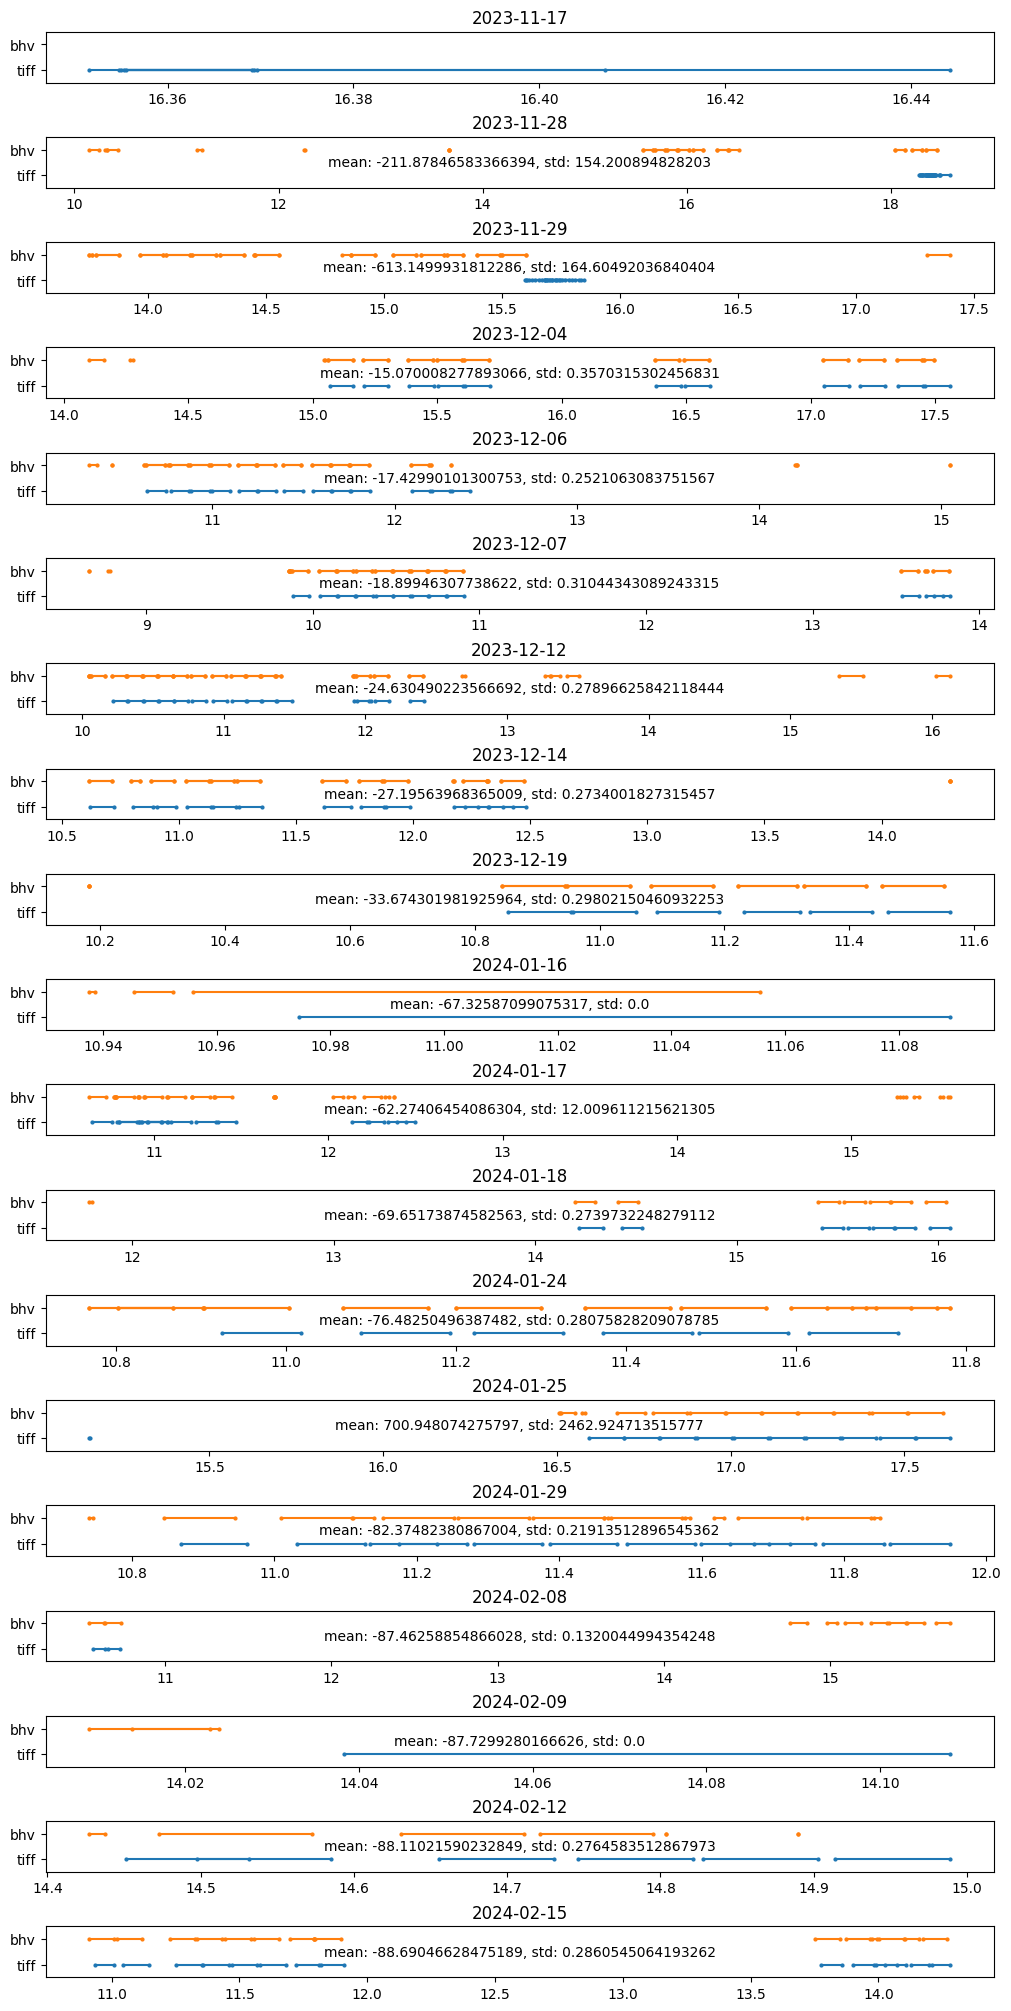

In [29]:
expt_dates = tiff_df['date'].unique()
fig, axs = plt.subplots(len(expt_dates), figsize=(10,20), layout="constrained")
for index, expt_date in enumerate(expt_dates):
    plot_expt_file_ranges(expt_date, tiff_df, bhv_df, axs[index])

In [30]:
# Is the delay for any given day the same?
# If so I can use that to align the tiff and behavioral data

### Check if the delay between tiff and bhv creation date is consistent during one recording session.

In [31]:
expt_date = date.fromisoformat("2024-01-24")
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

<Axes: title={'center': '2024-01-24'}>

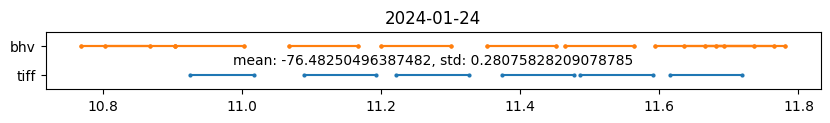

In [32]:
fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_ranges(expt_date, tiff_df, bhv_df, ax)

In [33]:
tiff_df_subset

,path,tiff,datetime,date,range,range_sub_midnight
138,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-01-24 10:55:27.349428,2024-01-24,"(1706122527.349428, 1706122862.2380688)","[10.924263729982906, 11.017288352449734]"
139,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-01-24 11:05:17.823446,2024-01-24,"(1706123117.823446, 1706123494.7796724)","[11.088284290565385, 11.192994353440072]"
140,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-01-24 11:13:15.311121,2024-01-24,"(1706123595.311121, 1706123972.2783194)","[11.220919755829705, 11.325632866488563]"
141,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-01-24 11:22:23.022630,2024-01-24,"(1706124143.02263, 1706124519.9854395)","[11.373061841660075, 11.477773733205265]"
142,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-01-24 11:29:07.759440,2024-01-24,"(1706124547.75944, 1706124924.746388)","[11.485488733318116, 11.59020732998848]"
143,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D6...,2024-01-24 11:36:52.628965,2024-01-24,"(1706125012.628965, 1706125389.6181073)","[11.614619156916937, 11.719338363144134]"


In [34]:
bhv_df_subset

,path,datetime,date,range,range_sub_midnight
567,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:40:53,2024-01-24,"(1706125253.0, 1706125612.2337646)","[11.681388888888888, 11.781176045735679]"
568,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:39:55,2024-01-24,"(1706125195.0, 1706125554.2461548)","[11.665277777777778, 11.765068376329209]"
569,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:38:08,2024-01-24,"(1706125088.0, 1706125447.2528687)","[11.635555555555555, 11.735348019070097]"
570,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:35:36,2024-01-24,"(1706124936.0, 1706125295.2893066)","[11.593333333333334, 11.693135918511285]"
571,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:27:51,2024-01-24,"(1706124471.0, 1706124830.2649841)","[11.464166666666667, 11.563962495591905]"
572,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:21:07,2024-01-24,"(1706124067.0, 1706124426.2813416)","[11.351944444444445, 11.451744817097982]"
573,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:11:59,2024-01-24,"(1706123519.0, 1706123878.282318)","[11.199722222222222, 11.299522866143121]"
574,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:04:01,2024-01-24,"(1706123041.0, 1706123400.2832947)","[11.066944444444443, 11.166745359632703]"
575,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 10:54:11,2024-01-24,"(1706122451.0, 1706122810.261078)","[10.903055555555556, 11.002850299411351]"
576,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 10:48:10,2024-01-24,"(1706122090.0, 1706122449.258545)","[10.802777777777777, 10.902571818033854]"


In [35]:
from datetime import datetime as dt

In [36]:
min_diffs = []
for i, tiff_row in tiff_df_subset.iterrows():
    print(tiff_row['path'].name)
    tiff_ts = tiff_row['datetime'].timestamp()
    min_diff = None
    for j, bhv_row in bhv_df_subset.iterrows():
        bhv_ts = bhv_row['datetime'].timestamp()
        diff = bhv_ts - tiff_ts
        if min_diff is None:
            min_diff = diff
        if diff > 0:
            continue
        if abs(diff) < abs(min_diff):
            min_diff = diff
            bhv_path = bhv_row['path']
    min_diffs.append(min_diff)

20240124_DR019xiGluSnFR_Fly01_00003.tif
20240124_DR019xiGluSnFR_Fly01_00004.tif
20240124_DR019xiGluSnFR_Fly01_00005.tif
20240124_DR019xiGluSnFR_Fly01_00006.tif
20240124_DR019xiGluSnFR_Fly01_00007.tif
20240124_DR019xiGluSnFR_Fly01_00008.tif


In [37]:
print(np.mean(min_diffs))
print(np.std(min_diffs))

-76.48250496387482
0.28075828209078785
